In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_train.csv
/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_sample_submission.csv
/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_test.csv


## 10. ⚙️ Preprocessing & Model Pipeline
Build the imputation, scaling, and LightGBM model pipeline used for both cross-validation and final predictions.

In [12]:
# ══════════════════════════════════════════════════════════════════
# 10. PREPROCESSING + MODEL PIPELINE
# ══════════════════════════════════════════════════════════════════
preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

model = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)

pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


## 11. ✅ Cross-Validation
Evaluate the pipeline using K-Fold cross-validation and report RMSE on the original (non-log) price scale.

In [13]:
# ══════════════════════════════════════════════════════════════════
# 11. CROSS-VALIDATION
# ══════════════════════════════════════════════════════════════════
kf = KFold(n_splits=3, shuffle=True, random_state=42)
rmse_list = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr_log, y_val = y_log.iloc[tr_idx], y.iloc[val_idx]

    pipeline.fit(X_tr, y_tr_log)
    val_pred = np.clip(np.expm1(pipeline.predict(X_val)), 0, None)

    fold_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    rmse_list.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

print(f"\nMean CV RMSE: {np.mean(rmse_list):.4f} (+/- {np.std(rmse_list):.4f})")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 1 RMSE: 0.4798


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 2 RMSE: 0.4703
Fold 3 RMSE: 0.4872

Mean CV RMSE: 0.4791 (+/- 0.0069)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 💡 Insight — Cross-Validation Results
The model achieves a mean CV RMSE of **0.4791** (± **0.0069**) across 3 folds (Fold 1: 0.4798, Fold 2: 0.4703, Fold 3: 0.4872). The low standard deviation (±0.007, under 1.5% of the mean) indicates the model is **stable and consistent across different data splits** — not overfitting to any particular fold. This is a solid improvement over the earlier RandomForest baseline (~0.51 RMSE).

## 12. 🌟 Feature Importance
Identify which engineered and original features the model relies on most — useful for validating EDA insights and guiding further iteration.

/tmp/ipykernel_16/3232648087.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


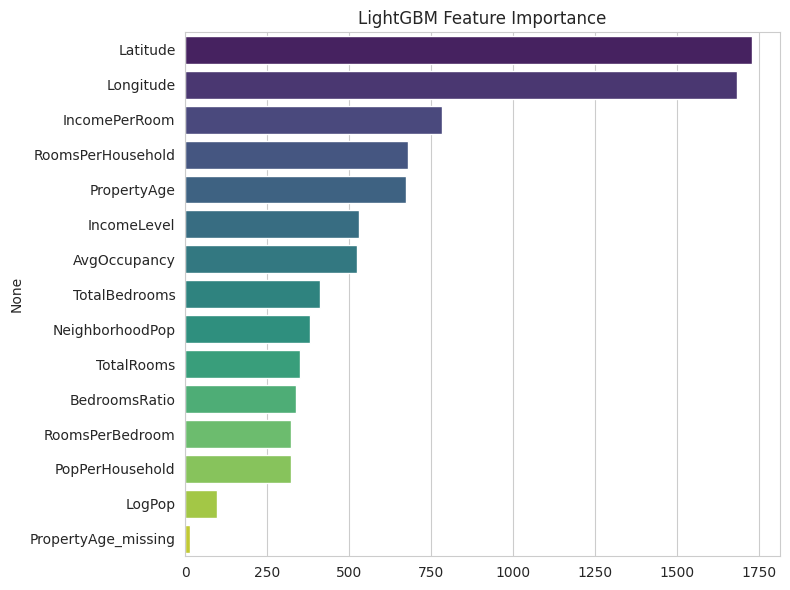


Top 5 most important features:
Latitude             1727
Longitude            1683
IncomePerRoom         783
RoomsPerHousehold     678
PropertyAge           674
dtype: int32


In [14]:
# ══════════════════════════════════════════════════════════════════
# 12. FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════════
pipeline.fit(X, y_log)
importances = pd.Series(
    pipeline.named_steps["model"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.head())

### 💡 Insight — Feature Importance
`Latitude` (1,727) and `Longitude` (1,683) are the two most important features by a wide margin — this makes strong real-world sense, as **location is historically the single biggest driver of California housing prices** (coastal vs inland, Bay Area vs Central Valley), even though neither showed a strong *linear* correlation with price in Section 5. This is a good example of why correlation heatmaps can be misleading — LightGBM captures non-linear, region-based pricing patterns that a simple Pearson correlation can't.

The engineered feature `IncomePerRoom` (783) ranks 3rd overall — validating that this feature genuinely added predictive value beyond the raw `IncomeLevel` and `TotalRooms` columns. `RoomsPerHousehold` (678) and `PropertyAge` (674) round out the top 5.